In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Choosing of Variables and Data Cleaning

In [31]:
df = pd.read_csv("NSFG_2022_2023_FemRespPUFData.csv")
df.head()

,CaseID,RSCRAGE,RSCRNINF,RSCRHISP,RSCRRACE,FTFMODE,DEVICE_TYPE,AGE_R,AGESCRN,HISP,...,CMLSTYR,CMJAN3YR,CMJAN4YR,CMJAN5YR,CMFIVYR,YEAR,QUARTER,PHASE1,PHASE2,PHASE3
0,96064,29,5,5,3,2,Mobile,29,29,5,...,1474,1441,1429,1417,1426,2,4,1,0,0
1,96066,18,5,1,4,2,PC,18,18,1,...,1471,1441,1429,1417,1423,2,2,1,1,1
2,96068,37,1,5,2,2,Mobile,37,37,5,...,1473,1441,1429,1417,1425,2,4,1,0,0
3,96071,40,1,5,3,2,PC,40,40,5,...,1468,1441,1429,1417,1420,2,2,1,0,0
4,96072,49,1,5,2,2,PC,49,49,5,...,1466,1441,1429,1417,1418,2,1,1,1,0


In [63]:
mapping = {'PREGNUM' : "num_pregnancy", 
           'CONSTAT1': "contraceptive_method", 
           'AGE_R': "Age",
           'MARSTAT': 'marital_status'}
df_filtered = df[mapping.keys()].rename(mapping, axis=1).copy()
print(df_filtered.info())
df_filtered.describe()
df_filtered

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5586 entries, 0 to 5585
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   num_pregnancy         5586 non-null   int64
 1   contraceptive_method  5586 non-null   int64
 2   Age                   5586 non-null   int64
 3   marital_status        5586 non-null   int64
dtypes: int64(4)
memory usage: 174.7 KB
None


,num_pregnancy,contraceptive_method,Age,marital_status
0,0,6,29,3
1,0,40,18,3
2,0,33,37,2
3,1,31,40,1
4,4,1,49,3
...,...,...,...,...
5581,0,42,20,3
5582,1,33,46,1
5583,0,33,22,1
5584,0,40,20,3


### Base on the codebook:
PREGNUM = Total number of pregnancies (including current) (Count Variable)

CONSTAT1 = Current contraceptive status - 1st priority (Categorical (nominal))

MARSTAT = AD-7b R's marital or cohabiting status (Ordered categorical)

AGE_R = R's age at interview (FC A-2b) (Demographics)

In [65]:
df_filtered['num_pregnancy'] = df_filtered['num_pregnancy'].fillna(0).astype(int)

mappings = {
    'marital_status': {
        1: "Married",
        2: "Living with partner",
        3: "Neither",
        8: "Refused",
        9: "Don't Know"
    },
    'contraceptive_method': {
        1: "Female sterilization",
        2: "Male sterilization",
        3: "Hormonal implant",
        5: "Depo-Provera (injectable)",
        6: "Pill",
        7: "Contraceptive Patch",
        8: "Contraceptive Ring",
        9: "Emergency contraception",
        10: "IUD",
        11: "Diaphragm",
        12: "Male condom",
        13: "Female condom",
        19: "Periodic abstinence (NFP, mucus, temp)",
        20: "Periodic abstinence (calendar rhythm)",
        21: "Withdrawal",
        22: "Other method",
        30: "Pregnant",
        31: "Seeking pregnancy",
        32: "Postpartum",
        33: "Sterile - nonsurgical (female)",
        34: "Sterile - nonsurgical (male)",
        35: "Sterile - surgical (female, noncontraceptive)",
        38: "Sterile - unknown reason (male)",
        40: "Never had intercourse",
        41: "Not in past 3 months",
        42: "Had intercourse in past 3 months"
    }
}

for col, mapping in mappings.items():
    if col in df_filtered.columns:
        df_filtered[col] = df_filtered[col].map(mapping)

df_filtered

,num_pregnancy,contraceptive_method,Age,marital_status
0,0,Pill,29,Neither
1,0,Never had intercourse,18,Neither
2,0,Sterile - nonsurgical (female),37,Living with partner
3,1,Seeking pregnancy,40,Married
4,4,Female sterilization,49,Neither
...,...,...,...,...
5581,0,Had intercourse in past 3 months,20,Neither
5582,1,Sterile - nonsurgical (female),46,Married
5583,0,Sterile - nonsurgical (female),22,Married
5584,0,Never had intercourse,20,Neither


In [67]:
# Handle missing data
df_filtered.isna().sum()

num_pregnancy           0
contraceptive_method    0
Age                     0
marital_status          0
dtype: int64

In [70]:
df_filtered.dtypes

num_pregnancy            int32
contraceptive_method    object
Age                      int64
marital_status          object
dtype: object

In [72]:
df_filtered.agg(['dtypes','nunique', 'unique']).T

,dtypes,nunique,unique
num_pregnancy,int32,15,"[0, 1, 4, 2, 3, 5, 7, 6, 8, 10, 9, 11, 12, 13,..."
contraceptive_method,object,26,"[Pill, Never had intercourse, Sterile - nonsur..."
Age,int64,36,"[29, 18, 37, 40, 49, 30, 25, 44, 28, 47, 21, 1..."
marital_status,object,5,"[Neither, Living with partner, Married, Refuse..."


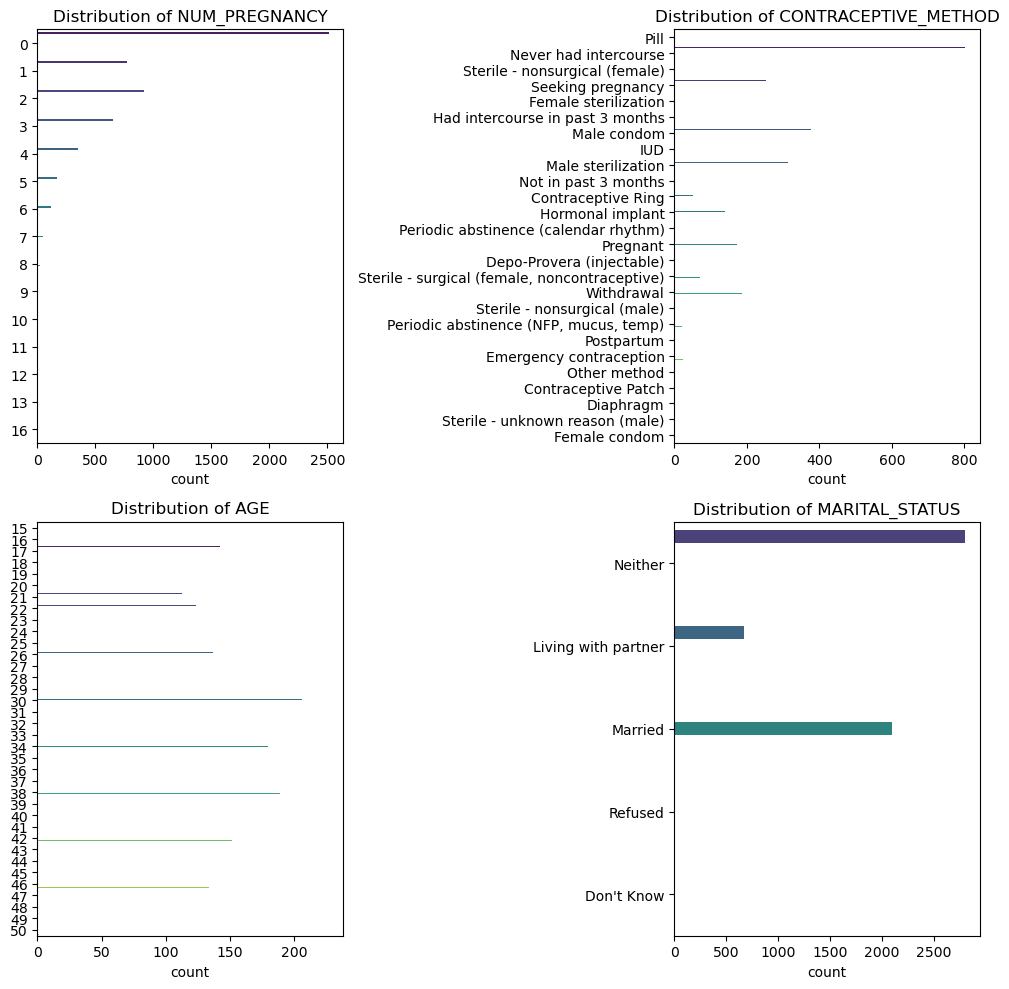

In [80]:
cols = df_filtered.columns
rows = int(np.ceil(len(cols)/2))
fig, ax = plt.subplots(ncols=2, nrows=rows, figsize=(10, 5*rows))
ax = ax.flatten()

for i, col in enumerate(cols):
    sns.countplot(
        data=df_filtered,
        y=col,
        hue=col,
        palette="viridis",
        ax=ax[i]
    )
    ax[i].tick_params(axis='y', labelsize=10)
    ax[i].set_ylabel('')
    ax[i].set_title(f"Distribution of {col.upper()}")
    ax[i].legend_.remove()

for j in range(len(cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

# Poission Regression

In [87]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_filtered['marital_status'] = df_filtered['marital_status'].astype('category')
df_filtered['contraceptive_method'] = df_filtered['contraceptive_method'].astype('category')

formula = 'num_pregnancy ~ Age + C(marital_status) + C(contraceptive_method)'

poisson_model = smf.poisson(formula=formula, data=df_filtered).fit()

print(poisson_model.summary())


         Current function value: 1.470068
         Iterations: 35
                          Poisson Regression Results                          
Dep. Variable:          num_pregnancy   No. Observations:                 5586
Model:                        Poisson   Df Residuals:                     5555
Method:                           MLE   Df Model:                           30
Date:                Sat, 17 May 2025   Pseudo R-squ.:                  0.2182
Time:                        18:44:56   Log-Likelihood:                -8211.8
converged:                      False   LL-Null:                       -10504.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------
Intercept           

C:\Users\spike\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [91]:
mean_count = df_filtered['num_pregnancy'].mean()
var_count = df_filtered['num_pregnancy'].var()

print(f"Mean of count outcome: {mean_count:.2f}")
print(f"Variance of count outcome: {var_count:.2f}")


Mean of count outcome: 1.48
Variance of count outcome: 3.26


If variance >> mean, there may be overdispersion (Poisson may not fit well).

# Contingency Tables


In [97]:
ct = pd.crosstab(df_filtered['contraceptive_method'], df_filtered['marital_status'])
print(ct)

marital_status                                 Don't Know  \
contraceptive_method                                        
Contraceptive Patch                                     0   
Contraceptive Ring                                      0   
Depo-Provera (injectable)                               0   
Diaphragm                                               0   
Emergency contraception                                 0   
Female condom                                           0   
Female sterilization                                    0   
Had intercourse in past 3 months                        0   
Hormonal implant                                        0   
IUD                                                     1   
Male condom                                             0   
Male sterilization                                      0   
Never had intercourse                                   0   
Not in past 3 months                                    0   
Other method            

In [99]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)

print(f"Chi-square statistic = {chi2:.2f}")
print(f"Degrees of freedom = {dof}")
print(f"P-value = {p:.4f}")

# Optional: see expected frequencies
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print("\nExpected Frequencies:")
print(expected_df.round(1))


Chi-square statistic = 1504.32
Degrees of freedom = 100
P-value = 0.0000

Expected Frequencies:
marital_status                                 Don't Know  \
contraceptive_method                                        
Contraceptive Patch                                   0.0   
Contraceptive Ring                                    0.0   
Depo-Provera (injectable)                             0.0   
Diaphragm                                             0.0   
Emergency contraception                               0.0   
Female condom                                         0.0   
Female sterilization                                  0.1   
Had intercourse in past 3 months                      0.1   
Hormonal implant                                      0.0   
IUD                                                   0.1   
Male condom                                           0.1   
Male sterilization                                    0.1   
Never had intercourse                             

If p < 0.05, there's a statistically significant association between contraceptive method and marital status.

If p >= 0.05, there's no evidence of association — variables are independent.

Since the p-value is far below 0.05, we reject the null hypothesis.

There is a statistically significant association between contraceptive method and marital status.

This means the distribution of contraceptive methods varies by marital status — they are not independent.

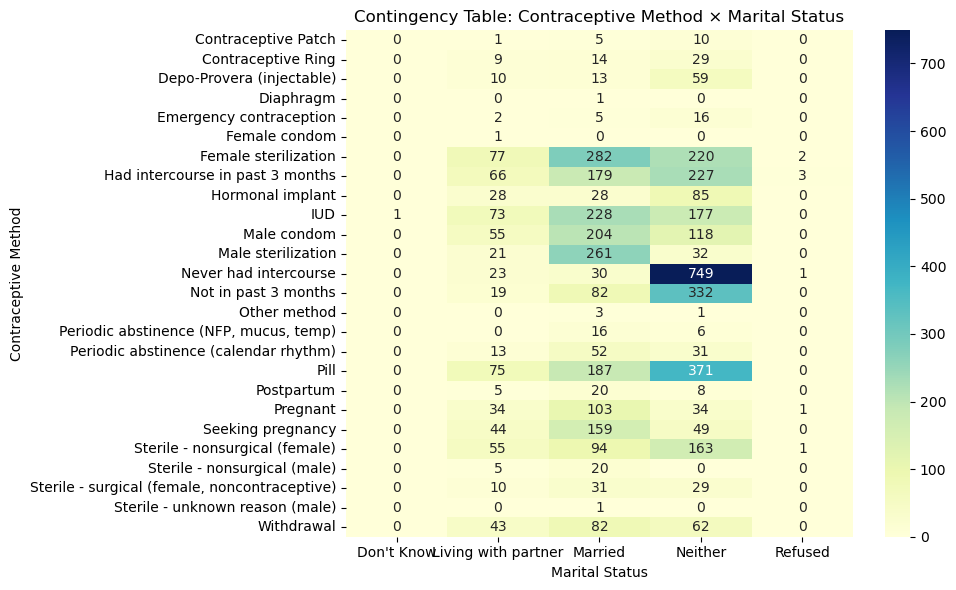

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Contingency Table: Contraceptive Method × Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Contraceptive Method')
plt.tight_layout()
plt.show()


# Categorical Response Modeling

#  EDA and Multiple Comparisons

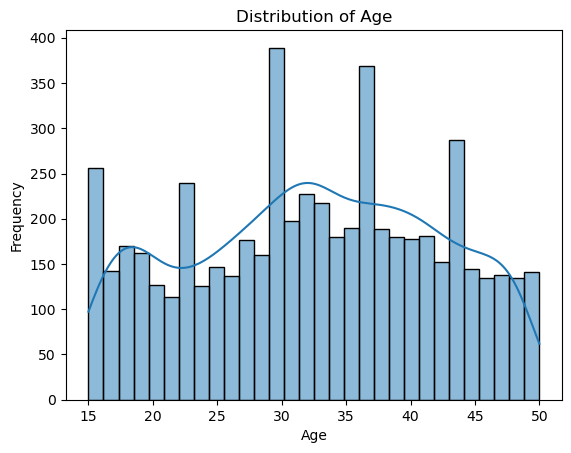

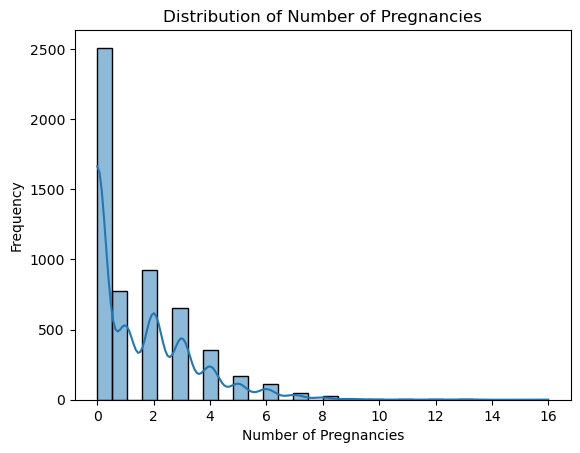

In [117]:
# Histogram for Age
sns.histplot(df_filtered['Age'], kde=True, bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Histogram for Number of Pregnancies
sns.histplot(df_filtered['num_pregnancy'], kde=True, bins=30)
plt.title("Distribution of Number of Pregnancies")
plt.xlabel("Number of Pregnancies")
plt.ylabel("Frequency")
plt.show()

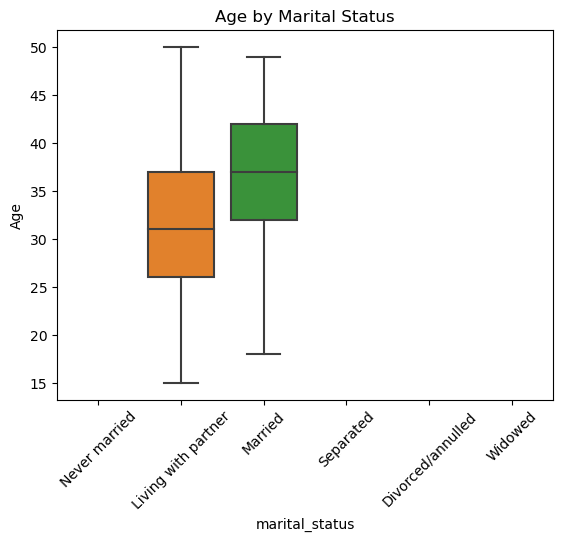

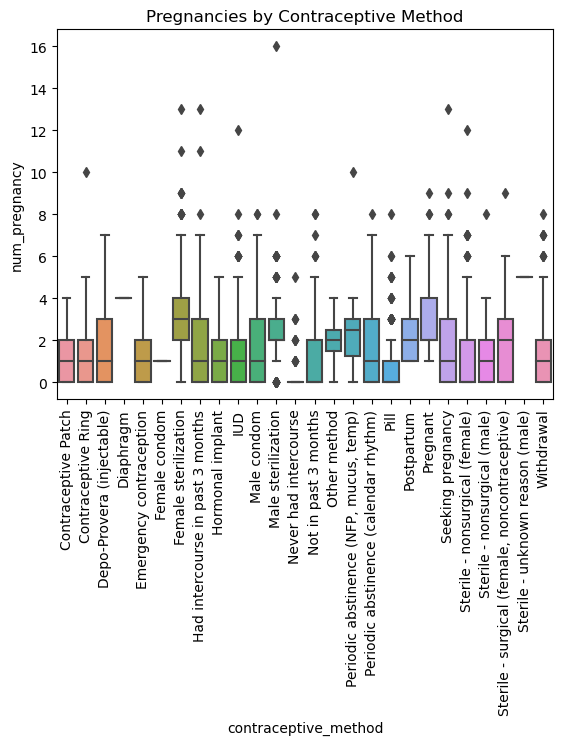

In [119]:
# Boxplot of Age by Marital Status
sns.boxplot(x='marital_status', y='Age', data=df_filtered)
plt.title("Age by Marital Status")
plt.xticks(rotation=45)
plt.show()

# Boxplot of Number of Pregnancies by Contraceptive Method
sns.boxplot(x='contraceptive_method', y='num_pregnancy', data=df_filtered)
plt.title("Pregnancies by Contraceptive Method")
plt.xticks(rotation=90)
plt.show()

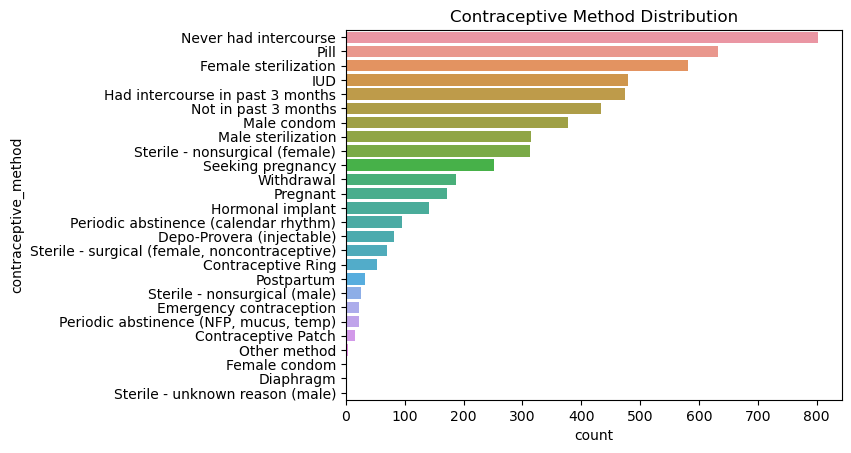

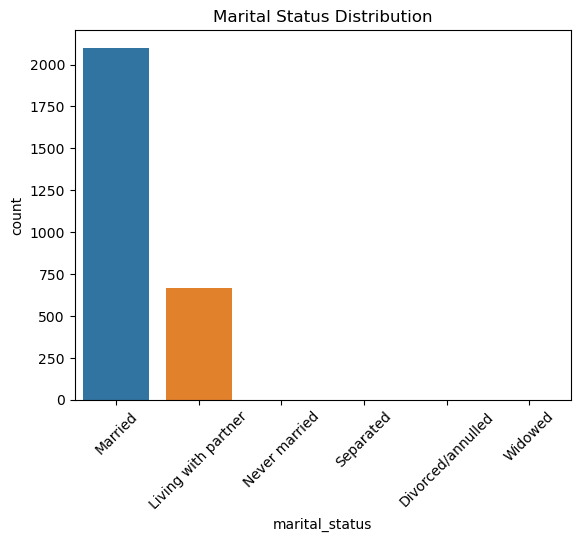

In [121]:
# Count of each contraceptive method
sns.countplot(y='contraceptive_method', data=df_filtered, order=df_filtered['contraceptive_method'].value_counts().index)
plt.title("Contraceptive Method Distribution")
plt.show()

# Count of marital status
sns.countplot(x='marital_status', data=df_filtered, order=df_filtered['marital_status'].value_counts().index)
plt.title("Marital Status Distribution")
plt.xticks(rotation=45)
plt.show()